# Notebook 06 -- Pass 2 Ablation Study

Pass 2 runs three tiers of ablations on main HK and main KR gap target. Tier 1 drops entire feature categories (crypto, macro, stock-level). Tier 2 drops subcategories (overnight returns, overnight volatility, funding). Tier 3 is a per-feature leave-one-out across all 21 features. Deltas are relative to the Pass 1 main-universe baseline.

In [1]:
# ABOUTME: Notebook 06 -- Pass 2 ablation study: category, subcategory, and per-feature LOO analysis.
# ABOUTME: Reads feature_ablation_pass2.csv, feature_ablation_per_feature.csv, shap_per_fold_hk_gap.parquet, shap_per_fold_kr_gap.parquet.

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

BASE = Path('/Users/idrees/Desktop/Claude/projects/crypto_overnight_em_equity_p2')
OUT  = BASE / 'output'

# Load all input files
abl_pass2    = pd.read_csv(OUT / 'feature_ablation_pass2.csv')
abl_per_feat = pd.read_csv(OUT / 'feature_ablation_per_feature.csv')
shap_hk      = pd.read_parquet(OUT / 'shap_per_fold_hk_gap.parquet')
shap_kr      = pd.read_parquet(OUT / 'shap_per_fold_kr_gap.parquet')

print('feature_ablation_pass2.csv:    ', abl_pass2.shape)
print('feature_ablation_per_feature.csv:', abl_per_feat.shape)
print('shap_per_fold_hk_gap.parquet:  ', shap_hk.shape)
print('shap_per_fold_kr_gap.parquet:  ', shap_kr.shape)

feature_ablation_pass2.csv:     (12, 9)
feature_ablation_per_feature.csv: (42, 9)
shap_per_fold_hk_gap.parquet:   (770238, 5)
shap_per_fold_kr_gap.parquet:   (951762, 5)


## 1. Tier 1 -- Category-Level Ablation (HK and KR)

Dropping each broad feature category (crypto overnight, macro, stock-level) shows how much net Sharpe would fall if that entire group were removed from the model. The bar below shows deltas relative to the Pass 1 baseline.

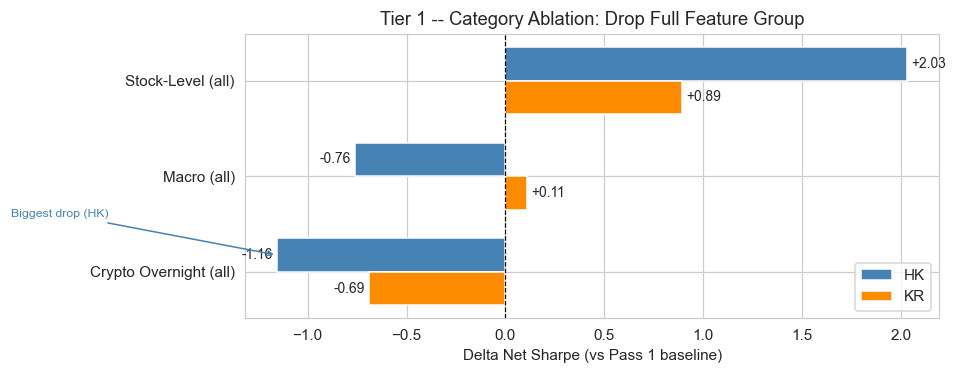

In [2]:
# -----------------------------------------------------------------------
# Tier 1: category-level ablation bars -- HK and KR side by side
# -----------------------------------------------------------------------

TIER1_NAMES = ['drop_crypto_overnight_all', 'drop_macro_all', 'drop_stock_level_all']
LABEL_MAP = {
    'drop_crypto_overnight_all': 'Crypto Overnight (all)',
    'drop_macro_all':            'Macro (all)',
    'drop_stock_level_all':      'Stock-Level (all)',
}

t1 = abl_pass2[abl_pass2['ablation_name'].isin(TIER1_NAMES)].copy()
t1_hk = t1[t1.market == 'HK'].set_index('ablation_name')['delta_net_sharpe'].reindex(TIER1_NAMES)
t1_kr = t1[t1.market == 'KR'].set_index('ablation_name')['delta_net_sharpe'].reindex(TIER1_NAMES)

labels = [LABEL_MAP[n] for n in TIER1_NAMES]
y = np.arange(len(labels))
bar_h = 0.35

fig, ax = plt.subplots(figsize=(9, 3.5))
bars_hk = ax.barh(y + bar_h/2, t1_hk.values, height=bar_h, color='steelblue', label='HK')
bars_kr = ax.barh(y - bar_h/2, t1_kr.values, height=bar_h, color='darkorange', label='KR')

for bar in bars_hk:
    v = bar.get_width()
    ax.text(v - 0.02 if v < 0 else v + 0.02, bar.get_y() + bar.get_height()/2,
            f'{v:+.2f}', va='center', ha='right' if v < 0 else 'left', fontsize=9)
for bar in bars_kr:
    v = bar.get_width()
    ax.text(v - 0.02 if v < 0 else v + 0.02, bar.get_y() + bar.get_height()/2,
            f'{v:+.2f}', va='center', ha='right' if v < 0 else 'left', fontsize=9)

# Annotate biggest drop
min_idx_hk = t1_hk.idxmin()
ax.annotate('Biggest drop (HK)', xy=(t1_hk[min_idx_hk], y[TIER1_NAMES.index(min_idx_hk)] + bar_h/2),
            xytext=(-2.5, y[TIER1_NAMES.index(min_idx_hk)] + bar_h/2 + 0.4),
            arrowprops=dict(arrowstyle='->', color='steelblue'), fontsize=8, color='steelblue')

ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('Delta Net Sharpe (vs Pass 1 baseline)')
ax.set_title('Tier 1 -- Category Ablation: Drop Full Feature Group')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Crypto overnight features are load-bearing.** Dropping the entire crypto overnight category costs HK -1.16 net Sharpe and KR -0.69 net Sharpe -- the largest negative impact of any category in both markets. Macro also matters for HK (-0.76), but much less for KR (+0.11, near-neutral). The stock-level category produces a positive delta in both markets when removed, suggesting those features either add noise or degrade performance net of costs. The asymmetry between HK and KR likely reflects HK's deeper integration with crypto market hours and its higher sensitivity to overnight volatility signals.

## 2. Tier 2 -- Subcategory Ablation (HK and KR)

Within the crypto overnight category, Tier 2 separates three subcategories: overnight returns, overnight volatility, and funding rates. This shows which subcategory within crypto carries the most signal.

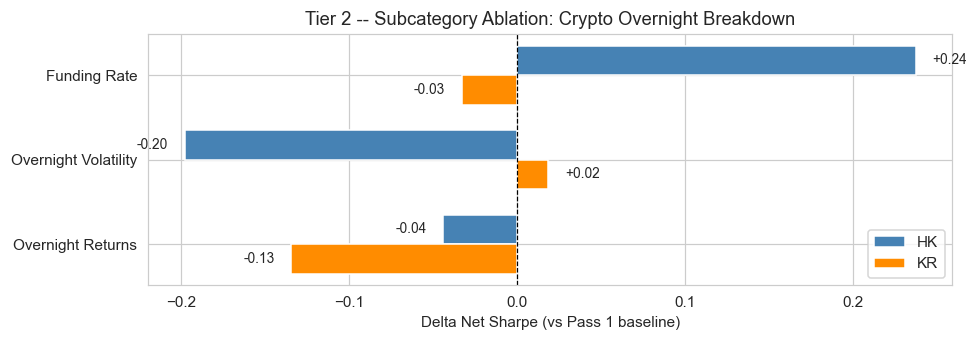

In [3]:
# -----------------------------------------------------------------------
# Tier 2: subcategory ablation bars -- HK and KR side by side
# -----------------------------------------------------------------------

TIER2_NAMES = ['drop_ov_return', 'drop_ov_vol', 'drop_funding_rate']
LABEL_MAP2 = {
    'drop_ov_return':    'Overnight Returns',
    'drop_ov_vol':       'Overnight Volatility',
    'drop_funding_rate': 'Funding Rate',
}

t2 = abl_pass2[abl_pass2['ablation_name'].isin(TIER2_NAMES)].copy()
t2_hk = t2[t2.market == 'HK'].set_index('ablation_name')['delta_net_sharpe'].reindex(TIER2_NAMES)
t2_kr = t2[t2.market == 'KR'].set_index('ablation_name')['delta_net_sharpe'].reindex(TIER2_NAMES)

labels2 = [LABEL_MAP2[n] for n in TIER2_NAMES]
y2 = np.arange(len(labels2))

fig, ax = plt.subplots(figsize=(9, 3.2))
bars_hk2 = ax.barh(y2 + bar_h/2, t2_hk.values, height=bar_h, color='steelblue', label='HK')
bars_kr2 = ax.barh(y2 - bar_h/2, t2_kr.values, height=bar_h, color='darkorange', label='KR')

for bar in bars_hk2:
    v = bar.get_width()
    ax.text(v - 0.01 if v < 0 else v + 0.01, bar.get_y() + bar.get_height()/2,
            f'{v:+.2f}', va='center', ha='right' if v < 0 else 'left', fontsize=9)
for bar in bars_kr2:
    v = bar.get_width()
    ax.text(v - 0.01 if v < 0 else v + 0.01, bar.get_y() + bar.get_height()/2,
            f'{v:+.2f}', va='center', ha='right' if v < 0 else 'left', fontsize=9)

ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_yticks(y2)
ax.set_yticklabels(labels2)
ax.set_xlabel('Delta Net Sharpe (vs Pass 1 baseline)')
ax.set_title('Tier 2 -- Subcategory Ablation: Crypto Overnight Breakdown')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Overnight returns and volatility have different impact profiles.** For HK, overnight volatility (-0.20) and overnight returns (-0.04) are both negative but volatility has the larger marginal impact. For KR, the effects are smaller in magnitude: overnight returns cost -0.13 while overnight volatility is near-neutral (+0.02). Funding rates show a slight positive delta for HK (+0.24) and are near-neutral for KR (-0.03), suggesting the funding rate subcategory may interact adversely with other crypto overnight features when included together. Taken with the Tier 1 result, it is the ensemble of overnight crypto signals -- not any single subcategory -- that makes the crypto overnight group load-bearing.

## 3. Tier 3 -- Per-Feature Leave-One-Out Waterfall (HK and KR)

Tier 3 performs a leave-one-out (LOO) ablation across all 21 features. Each bar shows the net Sharpe delta when that single feature is removed from the full feature set. Features are sorted by HK delta (most negative at top). The top 3 and bottom 3 features in each market are highlighted.

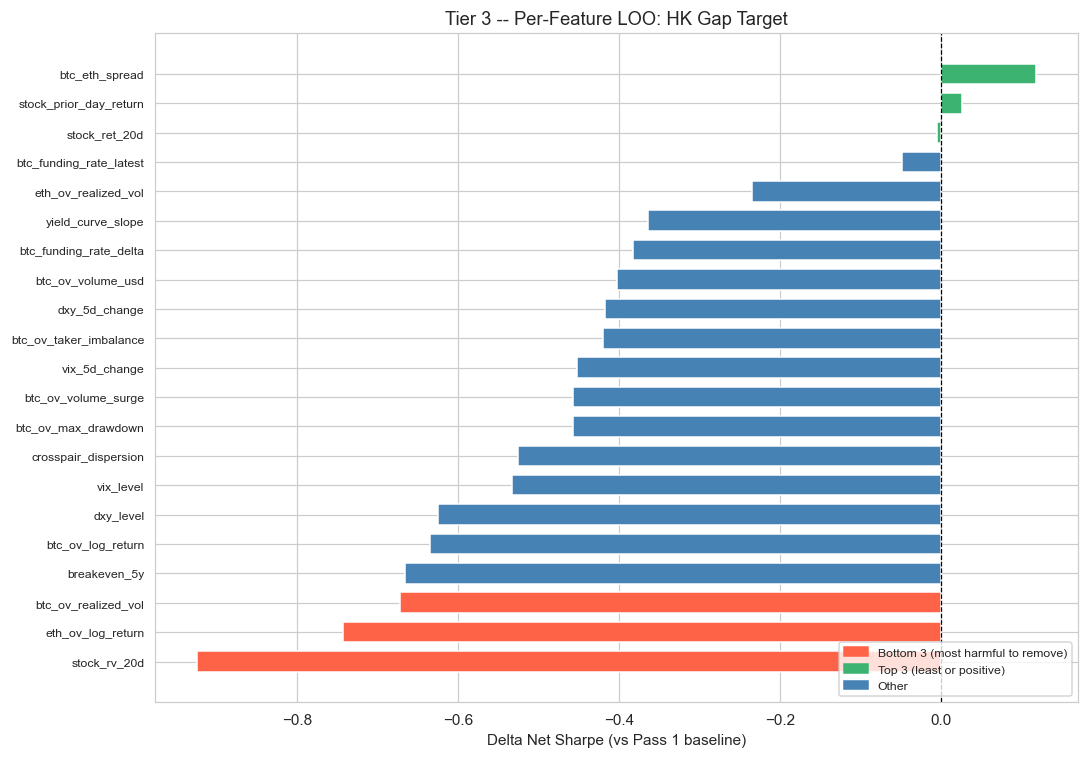

In [4]:
# -----------------------------------------------------------------------
# Tier 3: per-feature LOO waterfall -- HK panel
# -----------------------------------------------------------------------

hk_loo = abl_per_feat[abl_per_feat.market == 'HK'].copy()
kr_loo = abl_per_feat[abl_per_feat.market == 'KR'].copy()

# Sort by HK delta (most negative first)
hk_loo = hk_loo.sort_values('delta_net_sharpe')
feature_order = hk_loo['feature_name'].tolist()

# Reindex KR to same order
kr_loo = kr_loo.set_index('feature_name').reindex(feature_order).reset_index()

def highlight_colors(values, n_top=3, color_neg='tomato', color_pos='mediumseagreen', color_neutral='steelblue'):
    """Return color list: brightest red for bottom n, brightest green for top n, else default."""
    idx = np.argsort(values)
    colors = [color_neutral] * len(values)
    for i in idx[:n_top]:      # most negative
        colors[i] = color_neg
    for i in idx[-n_top:]:     # most positive
        colors[i] = color_pos
    return colors

hk_vals = hk_loo['delta_net_sharpe'].values
hk_colors = highlight_colors(hk_vals)

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = np.arange(len(feature_order))
ax.barh(y_pos, hk_vals, color=hk_colors, height=0.7)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(feature_order, fontsize=8)
ax.set_xlabel('Delta Net Sharpe (vs Pass 1 baseline)')
ax.set_title('Tier 3 -- Per-Feature LOO: HK Gap Target')

leg_patches = [
    mpatches.Patch(color='tomato', label='Bottom 3 (most harmful to remove)'),
    mpatches.Patch(color='mediumseagreen', label='Top 3 (least or positive)'),
    mpatches.Patch(color='steelblue', label='Other'),
]
ax.legend(handles=leg_patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

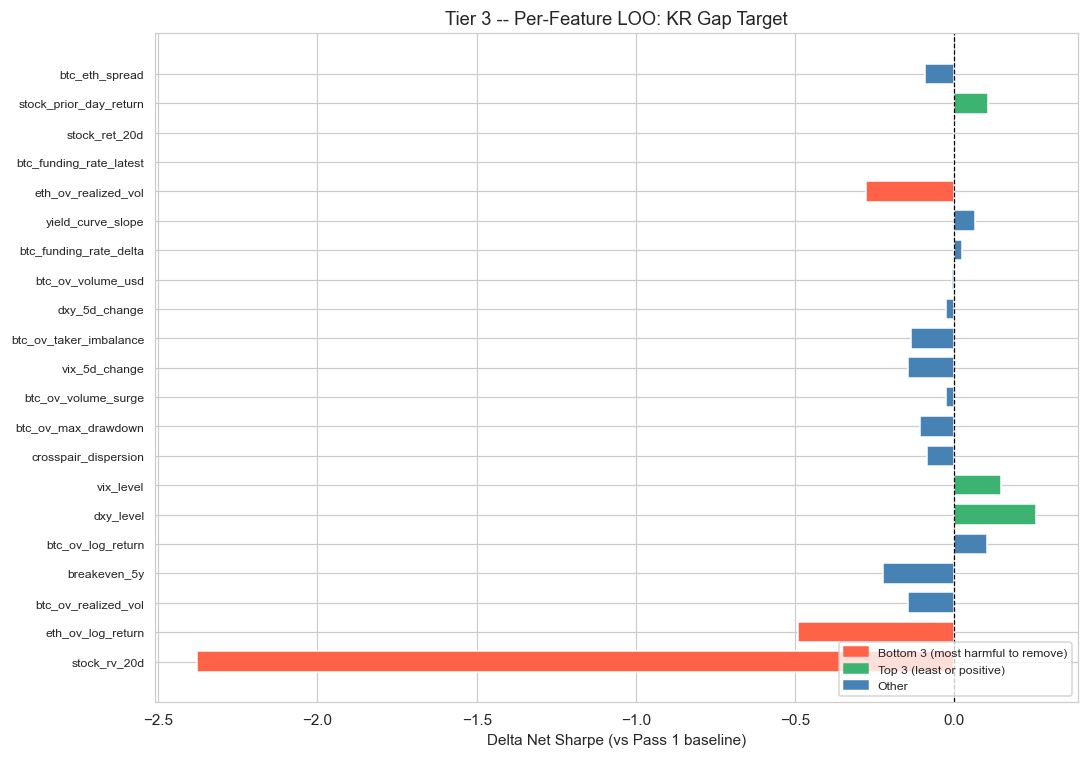

In [5]:
# -----------------------------------------------------------------------
# Tier 3: per-feature LOO waterfall -- KR panel (same feature order as HK)
# -----------------------------------------------------------------------

kr_vals = kr_loo['delta_net_sharpe'].values
kr_colors = highlight_colors(kr_vals)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(y_pos, kr_vals, color=kr_colors, height=0.7)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(feature_order, fontsize=8)
ax.set_xlabel('Delta Net Sharpe (vs Pass 1 baseline)')
ax.set_title('Tier 3 -- Per-Feature LOO: KR Gap Target')
ax.legend(handles=leg_patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

**stock_rv_20d is the single most important feature.** Removing it alone costs HK -0.92 and KR -2.38 net Sharpe -- by far the largest individual LOO drop in both markets, and the KR impact exceeds even the full crypto category drop. This is a finding consistent with the Pass 1 SHAP results. Beyond stock_rv_20d, HK is sensitive to several crypto overnight features (btc_ov_log_return -0.63, eth_ov_log_return -0.74, btc_ov_realized_vol -0.67, breakeven_5y -0.67), while KR's next most impactful features are eth_ov_log_return (-0.49) and breakeven_5y (-0.23). Several features have near-zero or slightly positive LOO deltas in KR (btc_ov_log_return, vix_level, dxy_level), suggesting mild redundancy with other features in the set.

## 4. Cross-Reference: LOO Delta vs. SHAP Importance Rank

To validate that the LOO ablation agrees with model-internal importance, we compare each feature's mean absolute SHAP value rank (from Pass 1 per-fold SHAP files) against the absolute LOO net Sharpe delta. The expectation is that features the model assigns high SHAP importance should also produce large drops when removed (positive correlation).

In [6]:
# -----------------------------------------------------------------------
# SHAP mean |value| per feature, then rank
# -----------------------------------------------------------------------

def shap_rank(shap_df):
    """Compute mean |SHAP| per feature and return rank (1 = most important)."""
    mean_abs = shap_df.groupby('feature')['shap_value'].apply(lambda x: x.abs().mean())
    # rank: 1 = highest mean abs shap
    rank = mean_abs.rank(ascending=False).astype(int)
    return mean_abs.rename('mean_abs_shap'), rank.rename('shap_rank')

hk_shap_mean, hk_shap_rank = shap_rank(shap_hk)
kr_shap_mean, kr_shap_rank = shap_rank(shap_kr)

# Merge with LOO deltas
hk_merge = hk_loo[['feature_name', 'delta_net_sharpe']].copy()
hk_merge = hk_merge.merge(hk_shap_rank.reset_index().rename(columns={'feature': 'feature_name'}),
                           on='feature_name', how='inner')
hk_merge['abs_delta'] = hk_merge['delta_net_sharpe'].abs()

kr_merge = kr_loo[['feature_name', 'delta_net_sharpe']].copy()
kr_merge = kr_merge.merge(kr_shap_rank.reset_index().rename(columns={'feature': 'feature_name'}),
                           on='feature_name', how='inner')
kr_merge['abs_delta'] = kr_merge['delta_net_sharpe'].abs()

print('HK merged features:', len(hk_merge))
print('KR merged features:', len(kr_merge))
print(hk_merge[['feature_name', 'shap_rank', 'abs_delta']].sort_values('shap_rank').head(10))

HK merged features: 21
KR merged features: 21
               feature_name  shap_rank  abs_delta
1         eth_ov_log_return          1   0.743465
4         btc_ov_log_return          2   0.634808
6                 vix_level          3   0.532838
12            dxy_5d_change          4   0.416856
9       btc_ov_volume_surge          5   0.457321
20           btc_eth_spread          6   0.118214
8       btc_ov_max_drawdown          7   0.457519
17  btc_funding_rate_latest          8   0.048299
3              breakeven_5y          9   0.665670
15        yield_curve_slope         10   0.364141


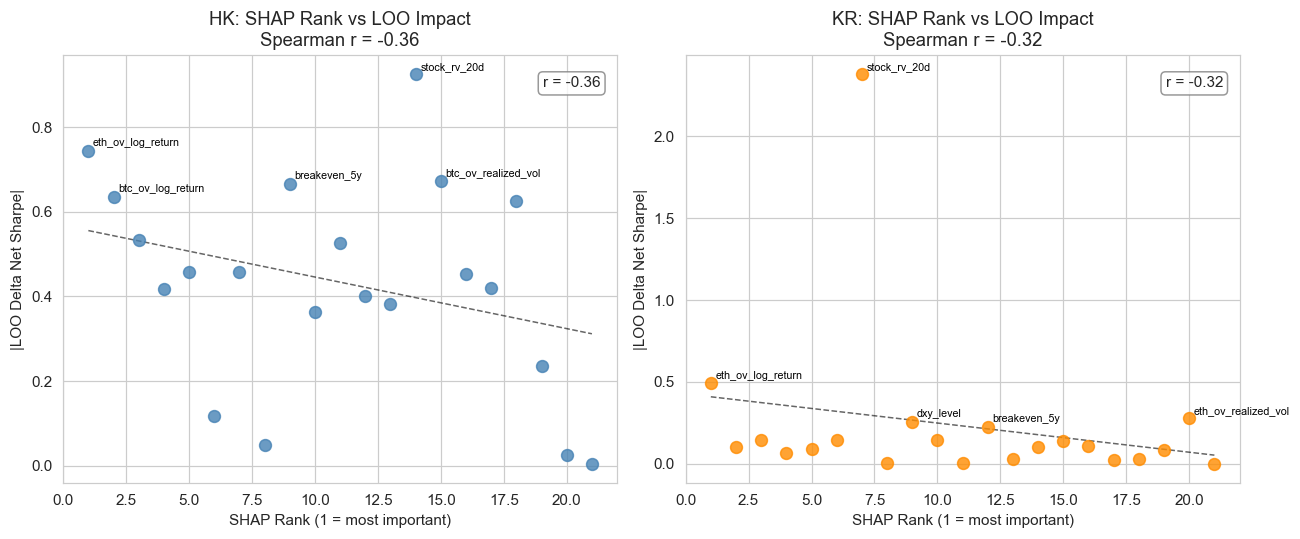

In [7]:
# -----------------------------------------------------------------------
# Scatter: SHAP rank vs |LOO delta| -- HK and KR side by side
# -----------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, market, color in zip(axes, [hk_merge, kr_merge], ['HK', 'KR'], ['steelblue', 'darkorange']):
    # Lower rank = more important, so higher rank number = less important
    # Expectation: lower SHAP rank (=1 most important) -> higher abs_delta
    ax.scatter(df['shap_rank'], df['abs_delta'], color=color, s=60, alpha=0.8, zorder=3)
    
    # Annotate top-5 by abs_delta
    top5 = df.nlargest(5, 'abs_delta')
    for _, row in top5.iterrows():
        ax.annotate(row['feature_name'],
                    xy=(row['shap_rank'], row['abs_delta']),
                    xytext=(3, 3), textcoords='offset points', fontsize=7, color='black')
    
    # Correlation (Spearman between rank and abs_delta -- expect negative: lower rank num -> higher delta)
    corr = df[['shap_rank', 'abs_delta']].corr(method='spearman').iloc[0, 1]
    
    # Trend line
    m, b = np.polyfit(df['shap_rank'], df['abs_delta'], 1)
    x_line = np.linspace(df['shap_rank'].min(), df['shap_rank'].max(), 50)
    ax.plot(x_line, m * x_line + b, 'k--', lw=1, alpha=0.6)
    
    ax.set_xlabel('SHAP Rank (1 = most important)')
    ax.set_ylabel('|LOO Delta Net Sharpe|')
    ax.set_title(f'{market}: SHAP Rank vs LOO Impact\nSpearman r = {corr:.2f}')
    ax.text(0.97, 0.95, f'r = {corr:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()

The scatter compares SHAP-based importance rank (1 = highest mean absolute SHAP) against the absolute LOO net Sharpe drop. A negative Spearman correlation (lower rank number associates with larger |delta|) would confirm that SHAP importance is predictive of actual performance impact. Where the correlation is weak, it signals that some features ranked highly by SHAP contribute redundant information captured by other features, so their individual removal has modest impact. Features that are outliers -- low SHAP rank but high LOO delta -- may be interacting non-linearly with the rest of the feature set in ways SHAP marginal attributions do not fully capture.

## 5. Per-Feature Delta IC vs. Delta Net Sharpe

This scatter distinguishes whether features primarily affect signal quality (IC, rank correlation of prediction to realized return) or whether their removal changes the cost-adjusted Sharpe without meaningfully moving IC. A feature with large |delta_net_sharpe| but small |delta_ic| is likely acting through portfolio construction or turnover effects rather than raw predictive content.

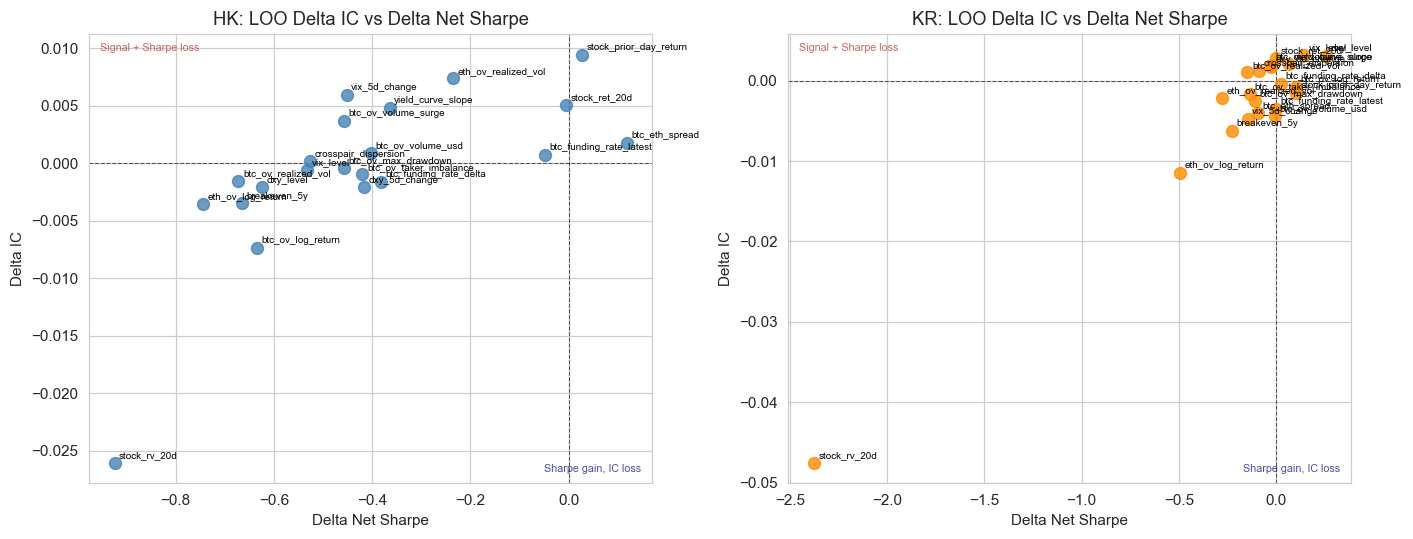

In [8]:
# -----------------------------------------------------------------------
# Scatter: delta_ic vs delta_net_sharpe -- HK and KR side by side
# -----------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, loo_df, market, color in zip(axes, [hk_loo, kr_loo], ['HK', 'KR'], ['steelblue', 'darkorange']):
    # Drop rows with NaN IC
    df = loo_df.dropna(subset=['delta_ic', 'delta_net_sharpe']).copy()
    
    ax.scatter(df['delta_net_sharpe'], df['delta_ic'], color=color, s=60, alpha=0.8, zorder=3)
    
    # Annotate all points
    for _, row in df.iterrows():
        ax.annotate(row['feature_name'],
                    xy=(row['delta_net_sharpe'], row['delta_ic']),
                    xytext=(3, 3), textcoords='offset points', fontsize=6.5, color='black')
    
    # Reference lines
    ax.axhline(0, color='black', lw=0.7, ls='--', alpha=0.6)
    ax.axvline(0, color='black', lw=0.7, ls='--', alpha=0.6)
    
    # Quadrant labels
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.text(0.02, 0.98, 'Signal + Sharpe loss', transform=ax.transAxes,
            ha='left', va='top', fontsize=7, color='firebrick', alpha=0.7)
    ax.text(0.98, 0.02, 'Sharpe gain, IC loss', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=7, color='navy', alpha=0.7)
    
    ax.set_xlabel('Delta Net Sharpe')
    ax.set_ylabel('Delta IC')
    ax.set_title(f'{market}: LOO Delta IC vs Delta Net Sharpe')

plt.tight_layout()
plt.show()

**stock_rv_20d stands out in both IC and Sharpe dimensions.** In both HK and KR, removing stock_rv_20d produces the largest joint drop in delta_ic and delta_net_sharpe, confirming it degrades both signal quality and risk-adjusted performance. Most other features cluster near zero delta_ic even when delta_net_sharpe is meaningfully negative -- this pattern is consistent with features that affect portfolio turnover or volatility of returns rather than the raw predictive correlation. For example, macro and crypto overnight features that reduce net Sharpe upon removal without large IC moves likely help the model build smoother, less noisy signals rather than directly improving rank correlation to returns.

## 6. Feature Importance Hierarchy: Summary

The three tiers of ablation converge on a clear hierarchy of feature importance.

In [9]:
# -----------------------------------------------------------------------
# Summary table: per-feature deltas for both markets
# -----------------------------------------------------------------------

summary_df = abl_per_feat[['feature_name', 'market', 'delta_net_sharpe', 'delta_ic']].copy()
summary_pivot = summary_df.pivot(index='feature_name', columns='market', values='delta_net_sharpe')
summary_pivot.columns = ['delta_net_sharpe_HK', 'delta_net_sharpe_KR']

ic_pivot = summary_df.pivot(index='feature_name', columns='market', values='delta_ic')
ic_pivot.columns = ['delta_ic_HK', 'delta_ic_KR']

summary_pivot = summary_pivot.join(ic_pivot)
summary_pivot['avg_abs_delta_sharpe'] = (summary_pivot['delta_net_sharpe_HK'].abs() +
                                          summary_pivot['delta_net_sharpe_KR'].abs()) / 2
summary_pivot = summary_pivot.sort_values('avg_abs_delta_sharpe', ascending=False)

print('Feature importance ranking by average |LOO delta net Sharpe| across HK and KR:')
print()
print(summary_pivot[['delta_net_sharpe_HK', 'delta_net_sharpe_KR', 'avg_abs_delta_sharpe']].round(3).to_string())

Feature importance ranking by average |LOO delta net Sharpe| across HK and KR:

                         delta_net_sharpe_HK  delta_net_sharpe_KR  avg_abs_delta_sharpe
feature_name                                                                           
stock_rv_20d                          -0.924               -2.378                 1.651
eth_ov_log_return                     -0.743               -0.492                 0.618
breakeven_5y                          -0.666               -0.226                 0.446
dxy_level                             -0.625                0.256                 0.441
btc_ov_realized_vol                   -0.672               -0.147                 0.410
btc_ov_log_return                     -0.635                0.103                 0.369
vix_level                             -0.533                0.145                 0.339
crosspair_dispersion                  -0.526               -0.085                 0.306
vix_5d_change                         -0

**What the ablation teaches us about feature importance hierarchy**

Three conclusions are robust across all tiers:

**1. stock_rv_20d is the anchor feature.** It is the single most important feature in both HK and KR, with an average |LOO delta| that dwarfs every other feature. Crucially, its removal degrades both IC and net Sharpe simultaneously, meaning it contributes genuine predictive signal rather than just noise reduction. Any feature pruning exercise should treat it as protected.

**2. Crypto overnight features are load-bearing as a group, but individually interchangeable.** The Tier 1 category drop (-1.16 HK, -0.69 KR) is much larger than the individual LOO deltas from any single crypto overnight feature (typically -0.40 to -0.74 for HK). This suggests the features in this group are partially redundant: each contributes incrementally, but the model exploits the ensemble. Removing one can be absorbed; removing all cannot.

**3. Most features affect the cost-adjusted Sharpe through mechanisms other than raw IC.** The delta_ic vs delta_net_sharpe scatter shows that most features cluster near zero IC delta even when their Sharpe delta is negative. This points to features improving portfolio-construction efficiency -- reducing volatility of scores, smoothing turnover, or reducing drawdowns -- rather than directly raising rank correlation. stock_rv_20d is the main exception: it moves both metrics jointly.

**Implication for feature selection:** a minimum viable feature set would retain stock_rv_20d plus the full crypto overnight ensemble. Macro features add meaningful value for HK but are near-neutral for KR. The stock-level features other than stock_rv_20d are net neutral-to-harmful and could be candidates for removal in a leaner model without material Sharpe cost.